In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [5]:
df = pd.read_csv(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\data\cleaned_complaints.csv"
)

In [6]:
X = df["clean_text"]

y = df["Agency Name"]

In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


In [9]:
import joblib

joblib.dump(
    label_encoder,
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models\distilbert_model/label_encoder.pkl"
)

print("✅ Label Encoder Saved Successfully!")

✅ Label Encoder Saved Successfully!


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)


In [24]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


In [26]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=64
)


In [27]:
class ComplaintDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels)

In [28]:
train_dataset = ComplaintDataset(
    train_encodings,
    y_train.tolist()
)

test_dataset = ComplaintDataset(
    test_encodings,
    y_test.tolist()
)


In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2941.10it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=1,

    weight_decay=0.01,

    ##logging_dir="./logs",

    load_best_model_at_end=True
)

In [35]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": acc
    }

In [36]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [37]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.004855,0.005461,0.997625


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]


TrainOutput(global_step=104858, training_loss=0.009685576937495997, metrics={'train_runtime': 9000.4956, 'train_samples_per_second': 93.202, 'train_steps_per_second': 11.65, 'total_flos': 6946710255302400.0, 'train_loss': 0.009685576937495997, 'epoch': 1.0})

In [38]:
predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [39]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5393
           1       1.00      1.00      1.00       899
           2       1.00      1.00      1.00       129
           3       1.00      1.00      1.00      9816
           4       1.00      1.00      1.00      3587
           5       1.00      0.68      0.81      1569
           6       1.00      1.00      1.00     66193
           7       1.00      1.00      1.00      3484
           8       1.00      1.00      1.00     23412
           9       1.00      1.00      1.00     16651
          10       1.00      1.00      1.00       766
          11       0.99      1.00      1.00     75846
          12       1.00      1.00      1.00         8
          13       1.00      1.00      1.00       185
          14       1.00      1.00      1.00      1777

    accuracy                           1.00    209715
   macro avg       1.00      0.98      0.99    209715
weighted avg       1.00   

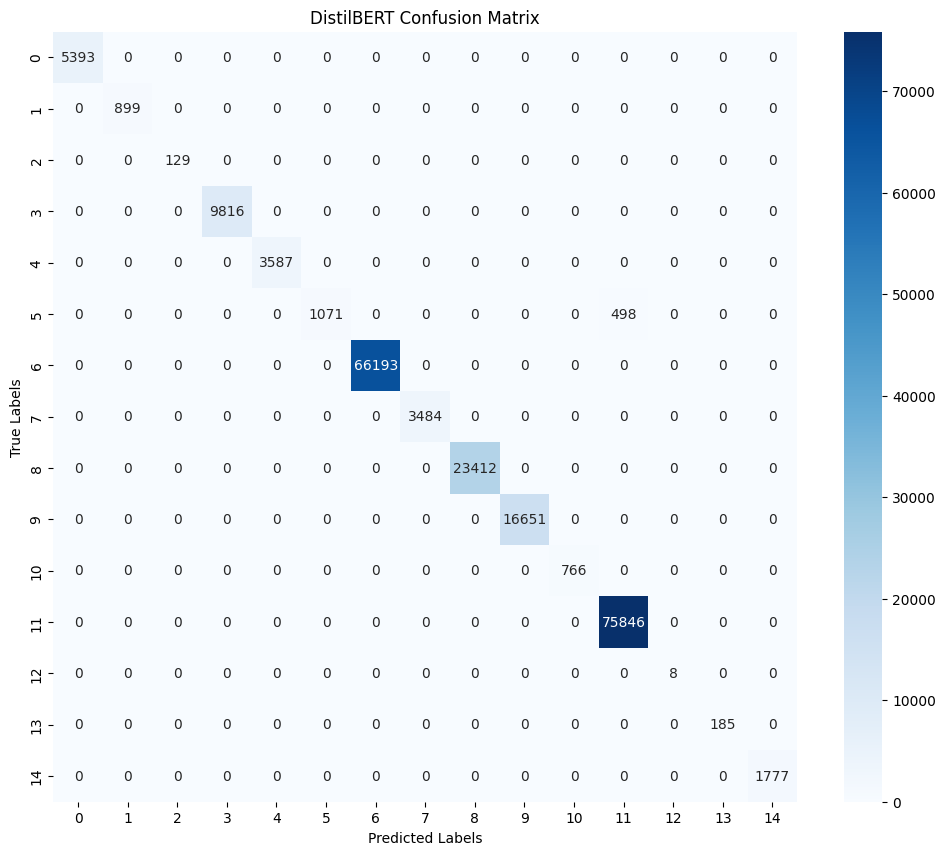

In [45]:
cm = confusion_matrix(
    y_test,
    preds
)

# Plot size
plt.figure(figsize=(12,10))

# Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Title
plt.title(
    "DistilBERT Confusion Matrix"
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

# Save plot
plt.savefig(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\outputs\distilbert_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

In [46]:
model.save_pretrained(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models\distilbert_model"
)

tokenizer.save_pretrained(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models\distilbert_model_tokenizer"
)

print("✅ DistilBERT Model Saved Successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]

✅ DistilBERT Model Saved Successfully!
